In [1]:
from pathlib import Path
from PIL import Image

DATASET_DIR = Path(
    r"C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr\Dataset\generated_plates\roya_bold"
)

bad_files = []

png_files = list(DATASET_DIR.rglob("*.png"))

print("Total PNG files:", len(png_files))

for i, path in enumerate(png_files):
    try:
        with Image.open(path) as img:
            img.verify()

        # دوباره باز می‌کنیم تا decode واقعی هم تست شود
        with Image.open(path) as img:
            img.load()

    except Exception as e:
        bad_files.append((path, str(e)))

    if (i + 1) % 5000 == 0:
        print(f"Checked: {i + 1}/{len(png_files)}")

print("\nBad files:", len(bad_files))

for path, error in bad_files[:50]:
    print(path)
    print("  Error:", error)

Total PNG files: 83592
Checked: 5000/83592
Checked: 10000/83592
Checked: 15000/83592
Checked: 20000/83592
Checked: 25000/83592
Checked: 30000/83592
Checked: 35000/83592
Checked: 40000/83592
Checked: 45000/83592
Checked: 50000/83592
Checked: 55000/83592
Checked: 60000/83592
Checked: 65000/83592
Checked: 70000/83592
Checked: 75000/83592
Checked: 80000/83592

Bad files: 0


In [1]:
%cd C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr
%ls
!.\.venv\Scripts\activate

C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr


c:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


 Volume in drive C is OS
 Volume Serial Number is D238-2529

 Directory of C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr

10/03/2026  09:04 PM    <DIR>          .
10/03/2026  09:41 AM    <DIR>          ..
10/03/2026  10:25 PM    <DIR>          .venv
10/01/2026  01:38 PM    <DIR>          Dataset
09/30/2026  11:32 PM    <DIR>          Models
10/03/2026  10:09 PM    <DIR>          Notebooks
09/29/2026  10:05 AM                92 requirements.txt
10/01/2026  11:06 AM    <DIR>          Src
               1 File(s)             92 bytes
               7 Dir(s)   2,362,134,528 bytes free


In [2]:
import tensorflow as tf

In [3]:
import argparse
import sys
from pathlib import Path

# import tensorflow as tf



In [4]:
DATA_DIR = Path("C:\\Users\\MEHDI\\Desktop\\Projects\\ALPR-Persian\\ocr\\Dataset\\generated_plates\\roya_bold").resolve()

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_crnn_model(
    input_shape=(32, 128, 1), # عرض تصویر معمولاً برای توالی‌ها بزرگ‌تر از ارتفاع است
    num_classes=45            # تعداد کلاس‌ها (شامل کاراکترها + علامت blank برای CTC)
):
    inputs = layers.Input(shape=input_shape, name="image_input")

    # ==========================================
    # 1. CNN Feature Extractor
    # ==========================================
    # Block 1
    x = layers.Conv2D(64, (3, 3), padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name="pool1")(x)

    # Block 2
    x = layers.Conv2D(128, (3, 3), padding="same", name="conv2")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name="pool2")(x)

    # Block 3 & 4
    x = layers.Conv2D(256, (3, 3), padding="same", name="conv3")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn3")(x)
    x = layers.ReLU(name="relu3")(x)

    x = layers.Conv2D(256, (3, 3), padding="same", name="conv4")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn4")(x)
    x = layers.ReLU(name="relu4")(x)
    x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1), name="pool3")(x)

    # Block 5 & 6
    x = layers.Conv2D(512, (3, 3), padding="same", name="conv5")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn5")(x)
    x = layers.ReLU(name="relu5")(x)

    x = layers.Conv2D(512, (3, 3), padding="same", name="conv6")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn6")(x)
    x = layers.ReLU(name="relu6")(x)
    x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1), name="pool4")(x)

    # Block 7
    x = layers.Conv2D(512, (3, 3), padding="same", name="conv7")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn7")(x)
    x = layers.ReLU(name="relu7")(x)

    # ==========================================
    # 2. Map to Sequence
    # ==========================================
    # ورودی در این مرحله ابعادی معادل (Batch, Height, Width, Channels) دارد.
    # ارتفاع به ۱ کاهش یافته (در ورودی H=32: 32 -> 16 -> 8 -> 4 -> 2 -> 1)
    # خروجی Reshape به صورت (Batch, Width, Height * Channels) در می‌آید.
    
    # تغییر ابعاد: تبدیل ارتفاع و کانال‌ها به یک بُعد ویژگی
    target_shape = (-1, x.shape[2], x.shape[1] * x.shape[3]) # (TimeSteps, Features)
    x = layers.Permute((2, 1, 3))(x) # جا به جایی عرض و ارتفاع جهت همخوانی با گام زمان
    x = layers.Reshape((-1, x.shape[2] * x.shape[3]), name="reshape")(x)

    # معادل لایه Linear(1024, 96) در مدل PyTorch
    x = layers.Dense(96, activation="relu", name="map2seq")(x)

    # ==========================================
    # 3. Recurrent Layers (BiLSTM)
    # ==========================================
    # rnn1: LSTM(96, 256, bidirectional=True)
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True), name="rnn1"
    )(x)

    # rnn2: LSTM(512, 256, bidirectional=True)
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True), name="rnn2"
    )(x)

    # ==========================================
    # 4. Classifier
    # ==========================================
    # خروجی احتمالات برای هر گام زمانی (Time Step)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CRNN_Image2Text")
    return model

# ساخت مدل
model = build_crnn_model(input_shape=(32, 128, 1), num_classes=45)
model.summary()

Model: "CRNN_Image2Text"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 128, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 32, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 16, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 32, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 8, 32, 256)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 8, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 32, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 8, 32, 256)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 8, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 4, 32, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 4, 32, 512)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (ReLU)                    │ (None, 4, 32, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 4, 32, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 4, 32, 512)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu6 (ReLU)                    │ (None, 4, 32, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 2, 32, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv7 (Conv2D)                  │ (None, 2, 32, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn7 (BatchNormalization)        │ (None, 2, 32, 512)     │         2,04

 Total params: 9,287,821 (35.43 MB)

 Trainable params: 9,283,341 (35.41 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [6]:
def ctc_loss_lambda(y_true, y_pred):
    # y_pred: (batch_size, time_steps, num_classes)
    # y_true: (batch_size, max_label_len)
    
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int32")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int32")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int32")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int32")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int32")

    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

# کامپایل مدل
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=ctc_loss_lambda)

In [7]:
from pathlib import Path

import numpy as np
import tensorflow as tf


# ============================================================
# VOCABULARY
# ============================================================

DIGITS = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

LETTERS = [
    "D",
    "S",
    "alef",
    "beh",
    "dal",
    "ein",
    "feh",
    "gaf",
    "ghaf",
    "he",
    "jim",
    "kaf",
    "lam",
    "mim",
    "noon",
    "peh",
    "sad",
    "seh",
    "shin",
    "sin",
    "ta",
    "teh",
    "vav",
    "ye",
    "zeh",
    "zhe",
]

VOCABULARY = DIGITS + LETTERS

TOKEN_TO_ID = {
    token: index + 1
    for index, token in enumerate(VOCABULARY)
}

ID_TO_TOKEN = {
    index + 1: token
    for index, token in enumerate(VOCABULARY)
}

MAX_LABEL_LEN = 8


# ============================================================
# LABEL ENCODING
# ============================================================

def encode_label(label_text: str):
    """
    Convert folder name into 8 OCR tokens.

    Example:

        19teh933_20

    becomes:

        [
            "1",
            "9",
            "teh",
            "9",
            "3",
            "3",
            "2",
            "0"
        ]

    The letter token is treated as ONE token.
    """

    label_text = label_text.strip()

    # --------------------------------------------------------
    # Split city code
    # --------------------------------------------------------

    parts = label_text.split("_")

    if len(parts) != 2:
        raise ValueError(
            f"Invalid plate folder name: {label_text!r}. "
            f"Expected format like: 19teh933_20"
        )

    main_part = parts[0]
    city_code = parts[1]

    # --------------------------------------------------------
    # Validate city code
    # --------------------------------------------------------

    if len(city_code) != 2 or not city_code.isdigit():
        raise ValueError(
            f"Invalid city code in plate: {label_text!r}"
        )

    # --------------------------------------------------------
    # First two digits
    # --------------------------------------------------------

    if len(main_part) < 6:
        raise ValueError(
            f"Invalid main plate section: {label_text!r}"
        )

    first_two = main_part[:2]

    if not first_two.isdigit():
        raise ValueError(
            f"First two characters must be digits: "
            f"{label_text!r}"
        )

    # --------------------------------------------------------
    # Extract letter token
    #
    # Example:
    #
    #     19teh933
    #       ^^
    #
    #     Actually "teh" is detected as the alphabetic
    #     sequence between the first 2 digits and final 3 digits.
    # --------------------------------------------------------

    remaining = main_part[2:]

    letter_end = 0

    while (
        letter_end < len(remaining)
        and remaining[letter_end].isalpha()
    ):
        letter_end += 1

    letter = remaining[:letter_end]
    middle_three = remaining[letter_end:]

    # --------------------------------------------------------
    # Validate letter
    # --------------------------------------------------------

    if not letter:
        raise ValueError(
            f"Letter token not found in plate: "
            f"{label_text!r}"
        )

    if letter not in LETTERS:
        raise ValueError(
            f"Unknown letter token {letter!r} "
            f"in plate {label_text!r}"
        )

    # --------------------------------------------------------
    # Validate middle three digits
    # --------------------------------------------------------

    if len(middle_three) != 3:
        raise ValueError(
            f"Expected 3 digits after letter in "
            f"{label_text!r}, got {middle_three!r}"
        )

    if not middle_three.isdigit():
        raise ValueError(
            f"Middle section must contain 3 digits: "
            f"{label_text!r}"
        )

    # --------------------------------------------------------
    # Build 8 tokens
    # --------------------------------------------------------

    tokens = (
        list(first_two)
        + [letter]
        + list(middle_three)
        + list(city_code)
    )

    # --------------------------------------------------------
    # Final length check
    # --------------------------------------------------------

    if len(tokens) != MAX_LABEL_LEN:
        raise ValueError(
            f"Expected {MAX_LABEL_LEN} tokens, "
            f"got {len(tokens)} for plate "
            f"{label_text!r}"
        )

    # --------------------------------------------------------
    # Convert tokens to integer IDs
    # --------------------------------------------------------

    encoded = []

    for token in tokens:

        if token not in TOKEN_TO_ID:
            raise ValueError(
                f"Unknown token {token!r} "
                f"in plate {label_text!r}"
            )

        encoded.append(
            TOKEN_TO_ID[token]
        )

    return np.asarray(
        encoded,
        dtype=np.int32
    )


# ============================================================
# LOAD ALL PLATES
# ============================================================

def load_dataset_from_folders(data_dir):
    """
    Expected structure:

        data_dir/
        ├── 19teh933_20/
        │   ├── 0.png
        │   ├── 1.png
        │   └── ...
        │
        ├── 52sin123_45/
        │   ├── 0.png
        │   └── ...
        │
        └── ...

    The folder name is the label.

    Returns:

        image_paths
        labels
        plate_ids
    """

    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(
            f"Dataset directory not found:\n"
            f"{data_dir.resolve()}"
        )

    plate_dirs = sorted(
        [
            path
            for path in data_dir.iterdir()
            if path.is_dir()
        ]
    )

    if not plate_dirs:
        raise RuntimeError(
            f"No plate directories found in:\n"
            f"{data_dir.resolve()}"
        )

    image_paths = []
    labels = []
    plate_ids = []

    # --------------------------------------------------------
    # Process each plate folder
    # --------------------------------------------------------

    for plate_dir in plate_dirs:

        plate_id = plate_dir.name

        # Encode folder name ONCE
        encoded_label = encode_label(
            plate_id
        )

        # ----------------------------------------------------
        # All PNG files belong to this plate
        # ----------------------------------------------------

        images = sorted(
            plate_dir.glob("*.png"),
            key=lambda path: (
                int(path.stem)
                if path.stem.isdigit()
                else path.stem
            )
        )

        if not images:
            print(
                f"Warning: no PNG images found in "
                f"{plate_dir}"
            )
            continue

        for image_path in images:

            image_paths.append(
                str(image_path)
            )

            labels.append(
                encoded_label
            )

            plate_ids.append(
                plate_id
            )

    if not image_paths:
        raise RuntimeError(
            f"No images found in:\n"
            f"{data_dir.resolve()}"
        )

    return (
        np.asarray(image_paths),
        np.asarray(labels, dtype=np.int32),
        np.asarray(plate_ids)
    )


# ============================================================
# IMAGE PROCESSING
# ============================================================

def process_sample(image_path, label):

    image = tf.io.read_file(
        image_path
    )

    image = tf.io.decode_png(
        image,
        channels=1
    )

    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    image = tf.image.resize(
        image,
        [32, 160]
    )

    return {
        "image_input": image
    }, label


# ============================================================
# DATASET
# ============================================================

def get_dataset(
    data_dir=None,
    batch_size=64,
    validation_split=0.2,
    seed=42
):

    # --------------------------------------------------------
    # Default path
    # --------------------------------------------------------

    if data_dir is None:

        data_dir = (
            Path(__file__).resolve().parent.parent
            / "Dataset"
            / "generated_plates"
            / "roya_bold"
        )

    # --------------------------------------------------------
    # Load dataset
    # --------------------------------------------------------

    (
        image_paths,
        labels,
        plate_ids
    ) = load_dataset_from_folders(
        data_dir
    )

    # --------------------------------------------------------
    # Split by UNIQUE PLATE
    #
    # IMPORTANT:
    # Do NOT split individual images.
    # All variations of one plate must stay
    # in the same split.
    # --------------------------------------------------------

    unique_plates = np.unique(
        plate_ids
    )

    num_plates = len(
        unique_plates
    )

    if num_plates < 2:
        raise RuntimeError(
            "At least 2 unique plates are required."
        )

    rng = np.random.default_rng(
        seed
    )

    shuffled_plates = unique_plates.copy()

    rng.shuffle(
        shuffled_plates
    )

    val_plate_count = max(
        1,
        int(
            num_plates
            * validation_split
        )
    )

    val_plate_ids = set(
        shuffled_plates[
            :val_plate_count
        ]
    )

    train_mask = np.array(
        [
            plate_id not in val_plate_ids
            for plate_id in plate_ids
        ],
        dtype=bool
    )

    val_mask = np.array(
        [
            plate_id in val_plate_ids
            for plate_id in plate_ids
        ],
        dtype=bool
    )

    train_paths = image_paths[
        train_mask
    ]

    train_labels = labels[
        train_mask
    ]

    val_paths = image_paths[
        val_mask
    ]

    val_labels = labels[
        val_mask
    ]

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    print("=" * 60)
    print("OCR DATASET")
    print("=" * 60)

    print(
        f"Dataset : {data_dir.resolve()}"
    )

    print(
        f"Unique plates : {num_plates}"
    )

    print(
        f"Total images : {len(image_paths)}"
    )

    print()

    print(
        f"Train plates : "
        f"{num_plates - val_plate_count}"
    )

    print(
        f"Validation plates : "
        f"{val_plate_count}"
    )

    print()

    print(
        f"Train images : "
        f"{len(train_paths)}"
    )

    print(
        f"Validation images : "
        f"{len(val_paths)}"
    )

    print("=" * 60)

    # --------------------------------------------------------
    # TensorFlow Dataset
    # --------------------------------------------------------

    AUTOTUNE = tf.data.AUTOTUNE

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                train_paths,
                train_labels
            )
        )
        .shuffle(
            buffer_size=min(
                len(train_paths),
                10000
            ),
            seed=seed,
            reshuffle_each_iteration=True
        )
        .map(
            process_sample,
            num_parallel_calls=AUTOTUNE
        )
        .batch(
            batch_size
        )
        .prefetch(
            AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                val_paths,
                val_labels
            )
        )
        .map(
            process_sample,
            num_parallel_calls=AUTOTUNE
        )
        .batch(
            batch_size
        )
        .prefetch(
            AUTOTUNE
        )
    )

    return train_ds, val_ds

In [8]:
import re
from collections import Counter

pattern = re.compile(r"^(\d{2})(.+?)(\d{3})_(\d{2})$")

letter_tokens = []

for plate_dir in DATA_DIR.iterdir():
    if not plate_dir.is_dir():
        continue

    match = pattern.match(plate_dir.name)

    if not match:
        print("Invalid:", plate_dir.name)
        continue

    first_two, letter, middle_three, city_code = match.groups()
    letter_tokens.append(letter)

counter = Counter(letter_tokens)

print("Unique letter tokens:", len(counter))
print(sorted(counter.keys()))

Unique letter tokens: 26
['D', 'S', 'alef', 'beh', 'dal', 'ein', 'feh', 'gaf', 'ghaf', 'he', 'jim', 'kaf', 'lam', 'mim', 'noon', 'peh', 'sad', 'seh', 'shin', 'sin', 'ta', 'teh', 'vav', 'ye', 'zeh', 'zhe']


In [9]:
print(LETTERS)
print("D" in LETTERS)
print("S" in LETTERS)

['D', 'S', 'alef', 'beh', 'dal', 'ein', 'feh', 'gaf', 'ghaf', 'he', 'jim', 'kaf', 'lam', 'mim', 'noon', 'peh', 'sad', 'seh', 'shin', 'sin', 'ta', 'teh', 'vav', 'ye', 'zeh', 'zhe']
True
True


In [10]:
train_ds, val_ds = get_dataset(Path(r"C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr\Dataset\generated_plates\roya_bold"))

OCR DATASET
Dataset : C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr\Dataset\generated_plates\roya_bold
Unique plates : 3098
Total images : 83613

Train plates : 2479
Validation plates : 619

Train images : 66900
Validation images : 16713


In [11]:
from PIL import Image
import matplotlib.pyplot as plt

In [12]:
batch = next(iter(train_ds))

print("Type:", type(batch))

if isinstance(batch, tuple):
    print("Tuple length:", len(batch))

    for i, item in enumerate(batch):
        print(f"\nItem {i}:")
        print("  Type:", type(item))

        if isinstance(item, dict):
            print("  Keys:", item.keys())

            for key, value in item.items():
                print(
                    f"  {key}: shape={value.shape}, dtype={value.dtype}"
                )

        else:
            print("  Shape:", item.shape)
            print("  Dtype:", item.dtype)

elif isinstance(batch, dict):
    print("Keys:", batch.keys())

    for key, value in batch.items():
        print(
            f"{key}: shape={value.shape}, dtype={value.dtype}"
        )

Type: <class 'tuple'>
Tuple length: 2

Item 0:
  Type: <class 'dict'>
  Keys: dict_keys(['image_input'])
  image_input: shape=(64, 32, 160, 1), dtype=<dtype: 'float32'>

Item 1:
  Type: <class 'tensorflow.python.framework.ops.EagerTensor'>
  Shape: (64, 8)
  Dtype: <dtype: 'int32'>


In [13]:
batch = next(iter(train_ds))

inputs = batch[0]
labels = batch[1]

images = inputs["image_input"]

for i in range(10):
    ids = labels[i].numpy()

    decoded = [
        ID_TO_TOKEN[int(x)]
        for x in ids
        if int(x) != 0
    ]

    print(f"{i}: {ids} -> {decoded}")

0: [ 2  3 32  7  6 10  5  3] -> ['1', '2', 'teh', '6', '5', '9', '4', '2']
1: [ 3  3 26  6 10  9  3  3] -> ['2', '2', 'peh', '5', '9', '8', '2', '2']
2: [ 2 10 29  8  3  5  9  1] -> ['1', '9', 'shin', '7', '2', '4', '8', '0']
3: [ 2 10 18  3 10  6  3  3] -> ['1', '9', 'gaf', '2', '9', '5', '2', '2']
4: [ 3  3 26  8  4  8  7  1] -> ['2', '2', 'peh', '7', '3', '7', '6', '0']
5: [ 2  8 12  4  5  9  9  9] -> ['1', '7', 'S', '3', '4', '8', '8', '8']
6: [ 2  4 35  9  9  9  7  7] -> ['1', '3', 'zeh', '8', '8', '8', '6', '6']
7: [ 3  2 16  9  6  9  5  6] -> ['2', '1', 'ein', '8', '5', '8', '4', '5']
8: [ 2 10 28  5  9 10 10  1] -> ['1', '9', 'seh', '4', '8', '9', '9', '0']
9: [ 2  6 16  9  5  4 10  9] -> ['1', '5', 'ein', '8', '4', '3', '9', '8']


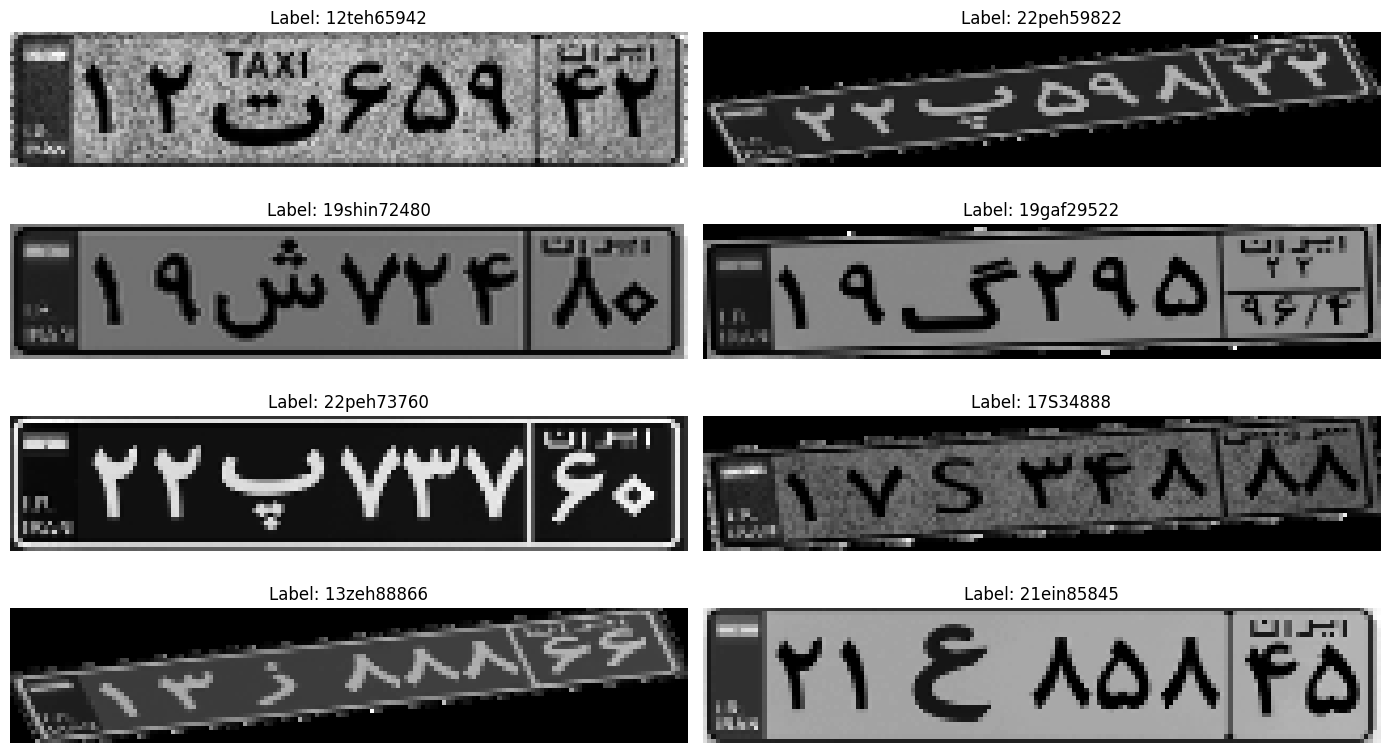

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(images[i].numpy().squeeze(), cmap="gray")

    decoded = "".join(
        ID_TO_TOKEN[int(x)]
        for x in labels[i].numpy()
        if int(x) != 0
    )

    ax.set_title(f"Label: {decoded}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_crnn_model(
    input_shape=(32, 128, 1), # عرض تصویر معمولاً برای توالی‌ها بزرگ‌تر از ارتفاع است
    num_classes=45            # تعداد کلاس‌ها (شامل کاراکترها + علامت blank برای CTC)
):
    inputs = layers.Input(shape=input_shape, name="image_input")

    # ==========================================
    # 1. CNN Feature Extractor
    # ==========================================
    # Block 1
    x = layers.Conv2D(64, (3, 3), padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name="pool1")(x)

    # Block 2
    x = layers.Conv2D(128, (3, 3), padding="same", name="conv2")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name="pool2")(x)

    # Block 3 & 4
    x = layers.Conv2D(256, (3, 3), padding="same", name="conv3")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn3")(x)
    x = layers.ReLU(name="relu3")(x)

    x = layers.Conv2D(256, (3, 3), padding="same", name="conv4")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn4")(x)
    x = layers.ReLU(name="relu4")(x)
    x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1), name="pool3")(x)

    # Block 5 & 6
    x = layers.Conv2D(512, (3, 3), padding="same", name="conv5")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn5")(x)
    x = layers.ReLU(name="relu5")(x)

    x = layers.Conv2D(512, (3, 3), padding="same", name="conv6")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn6")(x)
    x = layers.ReLU(name="relu6")(x)
    x = layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1), name="pool4")(x)

    # Block 7
    x = layers.Conv2D(512, (3, 3), padding="same", name="conv7")(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5, name="bn7")(x)
    x = layers.ReLU(name="relu7")(x)

    # ==========================================
    # 2. Map to Sequence
    # ==========================================
    # ورودی در این مرحله ابعادی معادل (Batch, Height, Width, Channels) دارد.
    # ارتفاع به ۱ کاهش یافته (در ورودی H=32: 32 -> 16 -> 8 -> 4 -> 2 -> 1)
    # خروجی Reshape به صورت (Batch, Width, Height * Channels) در می‌آید.
    
    # تغییر ابعاد: تبدیل ارتفاع و کانال‌ها به یک بُعد ویژگی
    target_shape = (-1, x.shape[2], x.shape[1] * x.shape[3]) # (TimeSteps, Features)
    x = layers.Permute((2, 1, 3))(x) # جا به جایی عرض و ارتفاع جهت همخوانی با گام زمان
    x = layers.Reshape((-1, x.shape[2] * x.shape[3]), name="reshape")(x)

    # معادل لایه Linear(1024, 96) در مدل PyTorch
    x = layers.Dense(96, activation="relu", name="map2seq")(x)

    # ==========================================
    # 3. Recurrent Layers (BiLSTM)
    # ==========================================
    # rnn1: LSTM(96, 256, bidirectional=True)
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True), name="rnn1"
    )(x)

    # rnn2: LSTM(512, 256, bidirectional=True)
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True), name="rnn2"
    )(x)

    # ==========================================
    # 4. Classifier
    # ==========================================
    # خروجی احتمالات برای هر گام زمانی (Time Step)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CRNN_Image2Text")
    return model

: 

In [ ]:
# ۱. دریافت دیتاست‌ها
train_ds, val_ds = get_dataset(DATA_DIR, batch_size=64)

# ۲. ساخت مدل (ابعاد تصویر 32x160 و تعداد کلاس‌ها برابر با طول Vocabulary + 1)
num_classes = len(VOCABULARY) + 2  # تعداد کل کاراکترها + OOV + Blank token در CTC
model = build_crnn_model(input_shape=(32, 160, 1), num_classes=num_classes)

# ۳. کامپایل مدل با CTC Loss
def ctc_loss_lambda(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=ctc_loss_lambda)

# ۴. اجرا
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

OCR DATASET
Dataset : C:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr\Dataset\generated_plates\roya_bold
Unique plates : 3098
Total images : 83613

Train plates : 2479
Validation plates : 619

Train images : 66900
Validation images : 16713
Epoch 1/25


c:\Users\MEHDI\Desktop\Projects\ALPR-Persian\ocr\.venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image_input
Received: inputs=['Tensor(shape=(None, 32, 160, 1))']
  warnings.warn(msg)
